## Runtime Setup

In [ ]:
!pip install -q captum==0.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.6 MB/s eta 0:00:00


In [ ]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # multi-GPU

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [ ]:
!gdown 14lX_JgofYZLbIkjPf7rXmBOpVIfMudDo -O kaggle.json
!mkdir -p /root/.kaggle
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download thedevastator/dailydialog-multi-turn-dialog-with-intention-and
!unzip dailydialog-multi-turn-dialog-with-intention-and.zip -d .

Downloading...
From: https://drive.google.com/uc?id=14lX_JgofYZLbIkjPf7rXmBOpVIfMudDo
To: /content/kaggle.json
100% 69.0/69.0 [00:00<00:00, 225kB/s]
Dataset URL: https://www.kaggle.com/datasets/thedevastator/dailydialog-multi-turn-dialog-with-intention-and
License(s): CC0-1.0
  0% 0.00/2.46M [00:00<?, ?B/s]
100% 2.46M/2.46M [00:00<00:00, 551MB/s]
Archive:  dailydialog-multi-turn-dialog-with-intention-and.zip
  inflating: ./test.csv              
  inflating: ./train.csv             
  inflating: ./validation.csv        


In [ ]:
# roberta fine tuned
!gdown 1lUGbp17pVLy9NkDa830rzRhrqomn9IHC -O train_embeddings_labels.zip
!gdown 14fgyoBQlSGq6x3ceUNzLHcFyHR-hTkuF -O val_embeddings_labels.zip
!gdown 1oAaVRGehIHmkWkcEcdVvBbwNfqdNZlJd -O test_embeddings_labels.zip

# Unzip all
!unzip train_embeddings_labels.zip
!unzip val_embeddings_labels.zip
!unzip test_embeddings_labels.zip

Downloading...
From (original): https://drive.google.com/uc?id=1lUGbp17pVLy9NkDa830rzRhrqomn9IHC
From (redirected): https://drive.google.com/uc?id=1lUGbp17pVLy9NkDa830rzRhrqomn9IHC&confirm=t&uuid=2d2281a1-e962-490b-b91a-55221ad3d886
To: /content/train_embeddings_labels.zip
100% 268M/268M [00:02<00:00, 127MB/s]
Downloading...
From: https://drive.google.com/uc?id=14fgyoBQlSGq6x3ceUNzLHcFyHR-hTkuF
To: /content/val_embeddings_labels.zip
100% 24.9M/24.9M [00:01<00:00, 18.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1oAaVRGehIHmkWkcEcdVvBbwNfqdNZlJd
To: /content/test_embeddings_labels.zip
100% 23.8M/23.8M [00:00<00:00, 88.6MB/s]
Archive:  train_embeddings_labels.zip
 extracting: train_embeddings.npy    
 extracting: train_labels.npy        
Archive:  val_embeddings_labels.zip
 extracting: val_embeddings.npy      
 extracting: val_labels.npy          
Archive:  test_embeddings_labels.zip
 extracting: test_embeddings.npy     
 extracting: test_labels.npy         


In [ ]:
!gdown 1_NSOp-5ZXdwzeUGrpVEwu6oNQVdHuuC5 -O best_model_transformer_fine_tuned.pt


Downloading...
From: https://drive.google.com/uc?id=1_NSOp-5ZXdwzeUGrpVEwu6oNQVdHuuC5
To: /content/best_model_transformer_fine_tuned.pt
100% 6.48M/6.48M [00:00<00:00, 11.7MB/s]


## Dataset and Embeddings Setup

In [ ]:
import pandas as pd
import ast
import re
from transformers import RobertaTokenizer

# Load original CSV files
df_train = pd.read_csv("train.csv")
df_val = pd.read_csv("validation.csv")
df_test = pd.read_csv("test.csv")

# Parse string representations of lists
def fix_and_eval_list(s):
    if isinstance(s, list):
        return s
    s_fixed = re.sub(r"(\d)\s+(?=\d)", r"\1, ", s)
    return ast.literal_eval(s_fixed)

# Extract utterances from quoted text
def parse_dialog(s):
    utterances = re.findall(r"'(.*?)'|\"(.*?)\"", s)
    return [u[0] if u[0] else u[1] for u in utterances]

# Apply parsing to all datasets
for df in [df_train, df_val, df_test]:
    df["dialog"] = df["dialog"].apply(parse_dialog)
    df["act"] = df["act"].apply(fix_and_eval_list)
    df["emotion"] = df["emotion"].apply(fix_and_eval_list)

# Flatten dialog-level dataset to turn-level format
def build_flat_df(df):
    rows = []
    for dialog_id, row in df.iterrows():
        for turn_id, (utt, emo) in enumerate(zip(row["dialog"], row["emotion"])):
            rows.append({
                "dialog_id": dialog_id,
                "turn_id": turn_id,
                "utterance": utt,
                "label": emo
            })
    return pd.DataFrame(rows)

df_train_flat = build_flat_df(df_train)
df_val_flat = build_flat_df(df_val)
df_test_flat = build_flat_df(df_test)

print(df_train_flat.shape, df_val_flat.shape, df_test_flat.shape)


(87170, 4) (8069, 4) (7740, 4)


In [ ]:
import numpy as np
import pandas as pd

# Load precomputed embeddings
train_embeddings = np.load("train_embeddings.npy")
val_embeddings = np.load("val_embeddings.npy")
test_embeddings = np.load("test_embeddings.npy")

# Insert embeddings into respective flat dataframes
df_train_flat["embedding"] = list(train_embeddings)
df_val_flat["embedding"] = list(val_embeddings)
df_test_flat["embedding"] = list(test_embeddings)

# Group utterance-level data into dialog-level sequences with embeddings
def group_embeddings_by_dialog(df_flat):
    grouped_embeddings = []
    grouped_labels = []
    for dialog_id, group in df_flat.groupby("dialog_id"):
        group = group.sort_values("turn_id")
        try:
            emb = np.stack(group["embedding"].values)
        except Exception as e:
            print(f"Skipping dialog_id {dialog_id} due to stacking error: {e}")
            continue
        labels = group["label"].values
        if emb.shape[0] != len(labels):
            print(f"Dropping dialog_id {dialog_id} - mismatch: {emb.shape[0]} embeddings vs {len(labels)} labels")
            continue
        grouped_embeddings.append(emb)
        grouped_labels.append(labels)
    return grouped_embeddings, grouped_labels

# Apply grouping to each split
train_dialog_embeddings, train_dialog_labels = group_embeddings_by_dialog(df_train_flat)
val_dialog_embeddings, val_dialog_labels = group_embeddings_by_dialog(df_val_flat)
test_dialog_embeddings, test_dialog_labels = group_embeddings_by_dialog(df_test_flat)

# Sanity check
print(train_dialog_embeddings[0].shape, train_dialog_labels[0])


(10, 768) [0 0 0 0 0 0 4 4 4 4]


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
batch_size = 256
class DialogDataset(torch.utils.data.Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = embeddings
        self.labels = labels

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        emb = torch.tensor(self.embeddings[idx], dtype=torch.float32)
        lbl = torch.tensor(self.labels[idx], dtype=torch.long)

        # Alterna speaker: 0,1,0,1,...
        spk = torch.tensor([i % 2 for i in range(len(lbl))], dtype=torch.long)

        return emb, lbl, spk

from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    emb_batch, lbl_batch, spk_batch = zip(*batch)

    emb_padded = pad_sequence(emb_batch, batch_first=True, padding_value=0.0)
    lbl_padded = pad_sequence(lbl_batch, batch_first=True, padding_value=-100)
    spk_padded = pad_sequence(spk_batch, batch_first=True, padding_value=0)

    lengths = torch.tensor([len(seq) for seq in lbl_batch], dtype=torch.long)

    return emb_padded, lbl_padded, spk_padded, lengths

train_dataset = DialogDataset(train_dialog_embeddings, train_dialog_labels)
val_dataset = DialogDataset(val_dialog_embeddings, val_dialog_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

test_dataset = DialogDataset(test_dialog_embeddings, test_dialog_labels)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

## Model Setup

In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class CustomTransformerEncoderLayer(nn.TransformerEncoderLayer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.attn_weights = None

    def forward(self, src, src_mask=None, is_causal=None, src_key_padding_mask=None):
        src2, attn_weights = self.self_attn(
            src, src, src,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False
        )
        self.attn_weights = attn_weights
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src


In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=768, speaker_dim=32, model_dim=256, num_heads=2, num_layers=2,
                 num_classes=7, dropout=0.2, max_len=100):
        super(TransformerClassifier, self).__init__()

        self.speaker_embedding = nn.Embedding(2, speaker_dim)
        self.input_projection = nn.Linear(input_dim + speaker_dim, model_dim)
        self.positional_embedding = nn.Embedding(max_len, model_dim)

        encoder_layer = CustomTransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=768,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.layer_norm = nn.LayerNorm(model_dim)
        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(model_dim, model_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(model_dim, num_classes)
        )

    def forward(self, x, lengths, speaker_ids):
        batch_size, seq_len, _ = x.shape

        spk_emb = self.speaker_embedding(speaker_ids)
        x_augmented = torch.cat([x, spk_emb], dim=-1)

        x_proj = self.input_projection(x_augmented)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        x_proj = x_proj + self.positional_embedding(positions)

        pad_mask = torch.arange(seq_len, device=lengths.device).expand(batch_size, seq_len) >= lengths.unsqueeze(1)
        out = self.transformer_encoder(x_proj, src_key_padding_mask=pad_mask)

        out = self.layer_norm(out)
        out = self.dropout(out)
        logits = self.classifier(out)
        return logits


In [ ]:
model = TransformerClassifier()
model.load_state_dict(torch.load("best_model_transformer_fine_tuned.pt"))
model.eval()
model.to(device)


TransformerClassifier(
  (speaker_embedding): Embedding(2, 32)
  (input_projection): Linear(in_features=800, out_features=256, bias=True)
  (positional_embedding): Embedding(100, 256)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x CustomTransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=768, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=768, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=

##Start

In [ ]:
all_preds = []

for emb_batch, labels_batch, spk_batch, lengths in test_loader:
    emb_batch = emb_batch.to(device)
    spk_batch = spk_batch.to(device)
    lengths = lengths.to(device)

    with torch.no_grad():
        logits = model(emb_batch, lengths, spk_batch)
        preds = torch.argmax(logits, dim=-1).cpu().numpy()  # shape: [batch_size, seq_len]

    # Salva le predizioni turn-by-turn
    for pred_seq, length in zip(preds, lengths.cpu().numpy()):
        all_preds.extend(pred_seq[:length])


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


In [ ]:
df_test_flat["predicted_label"] = all_preds


In [ ]:
emotion_map = {
    0: "no emotion", 1: "anger", 2: "disgust", 3: "fear",
    4: "happiness", 5: "sadness", 6: "surprise"
}

samples = []

for label_id in range(1, 7):
    emotion_name = emotion_map[label_id]

    correct = df_test_flat[
        (df_test_flat.label == label_id) & (df_test_flat.predicted_label == label_id)
    ]
    if not correct.empty:
        samples.append(
            correct.sample(1, random_state=42).assign(case="correct", emotion=emotion_name)
        )

    neutral_conf = df_test_flat[
        (df_test_flat.label == label_id) & (df_test_flat.predicted_label == 0)
    ]
    if not neutral_conf.empty:
        samples.append(
            neutral_conf.sample(1, random_state=42).assign(case="predicted as no emotion", emotion=emotion_name)
        )

    wrong_emo = df_test_flat[
        (df_test_flat.label == label_id) &
        (df_test_flat.predicted_label != 0) &
        (df_test_flat.predicted_label != label_id)
    ]
    if not wrong_emo.empty:
        samples.append(
            wrong_emo.sample(1, random_state=42).assign(case="confused with other emotion", emotion=emotion_name)
        )

df_dialog_examples = pd.concat(samples).reset_index(drop=True)
df_dialog_examples[["dialog_id", "turn_id", "utterance", "emotion", "label", "predicted_label", "case"]]


,dialog_id,turn_id,utterance,emotion,label,predicted_label,case
0,700,4,You know you didn't .,anger,1,1,correct
1,970,0,"I wonder what he looks like . Oh , I can't wai...",anger,1,0,predicted as no emotion
2,860,3,Yeah ... I know . But I'm sick and tired of a...,anger,1,2,confused with other emotion
3,376,1,"Oh , don't mention it . It was terrible .",disgust,2,2,correct
4,637,5,"Not yet , but I have to soon . He's eating me...",disgust,2,0,predicted as no emotion
5,197,1,Coffee ? I don ’ t honestly like that kind of...,disgust,2,6,confused with other emotion
6,461,0,I'm a little nervous .,fear,3,3,correct
7,100,2,But there are only two more days until the bi...,fear,3,0,predicted as no emotion
8,0,10,Yeah ?,fear,3,6,confused with other emotion
9,534,8,I love the bamboo flooring and granite counte...,happiness,4,4,correct


In [ ]:
from captum.attr import IntegratedGradients
import torch

# Target emotion labels: anger, fear, sadness
target_emotions = [1, 3, 5]

# Find a failure case: target emotion → predicted neutral
fallback_case = df_test_flat[
    (df_test_flat.label.isin(target_emotions)) &
    (df_test_flat.predicted_label == 0)
]

# Sample one example
example = fallback_case.sample(1, random_state=5).iloc[0]
dialog_id = example.dialog_id
turn_id = example.turn_id

# Retrieve full dialogue
dataset_index = df_test.index.get_loc(dialog_id)
emb, lbl, spk = test_dataset[dataset_index]
seq_len = len(lbl)

emb = emb.unsqueeze(0).to(device)
spk = spk.unsqueeze(0).to(device)
length = torch.tensor([seq_len], dtype=torch.long).to(device)

model.eval()

# Forward pass to get prediction
with torch.no_grad():
    logits = model(emb, length, spk)
    predicted_class = torch.argmax(logits[0, turn_id]).item()

# Extract mean attention map from all layers
attn_all = torch.stack([layer.attn_weights for layer in model.transformer_encoder.layers])
attn_map = attn_all[:, 0].mean(dim=(0, 1)).cpu().numpy()
attention_from_turn = attn_map[turn_id]

# Integrated Gradients saliency
def forward_func(inputs, speaker_ids):
    logits = model(inputs, length, speaker_ids)
    probs = torch.softmax(logits, dim=-1)
    return probs[:, turn_id, :]

ig = IntegratedGradients(forward_func)
attributions = ig.attribute(
    inputs=emb,
    additional_forward_args=spk,
    target=predicted_class,
    return_convergence_delta=False
)
saliencies = attributions.squeeze(0).norm(p=2, dim=1).cpu().numpy()
saliencies = saliencies / saliencies.sum()

# Print interpretation
print(f"Utterance:\n{example.utterance}")
print(f"\nTrue label: {emotion_map[example.label]} | Predicted: {emotion_map[example.predicted_label]}")
print(f"Dialog ID: {dialog_id}, Turn ID: {turn_id}")
print(f"\nAnalysis for turn {turn_id} (predicted: {emotion_map[predicted_class]})")

dialog_turns = df_test_flat[df_test_flat.dialog_id == dialog_id].sort_values("turn_id")

for _, row in dialog_turns.iterrows():
    i = row.turn_id
    attn = attention_from_turn[i] * 100
    sal = saliencies[i] * 100
    prefix = "→ " if i == turn_id else "  "
    print(f"{prefix}[{i}] {row.utterance}")
    print(f"{' ' * len(prefix)}    True: {emotion_map[row.label]}, Pred: {emotion_map[row.predicted_label]}")
    print(f"{' ' * len(prefix)}    Attention from turn {turn_id}: {attn:.2f} | IG score: {sal:.2f}")


Utterance:
 Says who ? I don't think that is necessarily the case . 

True label: anger | Predicted: no emotion
Dialog ID: 315, Turn ID: 5

Analysis for turn 5 (predicted: no emotion)
  [0] John , I was looking through some magazines for ideas about where we might go on vacation this year . 
      True: no emotion, Pred: no emotion
      Attention from turn 5: 3.07 | IG score: 1.00
  [1]  I've already told my buddy , Mark , that I am going hunting with him in Alaska . 
      True: no emotion, Pred: no emotion
      Attention from turn 5: 5.22 | IG score: 1.17
  [2]  You can't be serious ! 
      True: anger, Pred: surprise
      Attention from turn 5: 18.15 | IG score: 5.13
  [3]  Hey , I've always gone hunting or fishing on vacation . I am sorry that bothers you . 
      True: anger, Pred: no emotion
      Attention from turn 5: 22.66 | IG score: 6.76
  [4]  After a year together , I thought it pretty safe to assume that we would automatically spend our vacation together . 
      True

In [ ]:
from captum.attr import IntegratedGradients
import torch

# Select cases where anger is confused with disgust (and vice versa)
confused_case = df_test_flat[
    ((df_test_flat.label == 1) & (df_test_flat.predicted_label == 2)) |
    ((df_test_flat.label == 2) & (df_test_flat.predicted_label == 1))
]

# Sample one example
example = confused_case.sample(1, random_state=2).iloc[0]
dialog_id = example.dialog_id
turn_id = example.turn_id

# Load dialogue from dataset
dataset_index = df_test.index.get_loc(dialog_id)
emb, lbl, spk = test_dataset[dataset_index]
seq_len = len(lbl)

emb = emb.unsqueeze(0).to(device)
spk = spk.unsqueeze(0).to(device)
length = torch.tensor([seq_len], dtype=torch.long).to(device)

# Forward pass and prediction
model.eval()
with torch.no_grad():
    logits = model(emb, length, spk)
    predicted_class = torch.argmax(logits[0, turn_id]).item()

# Compute average attention across layers and heads
attn_all = torch.stack([layer.attn_weights for layer in model.transformer_encoder.layers])
attn_map = attn_all[:, 0].mean(dim=(0, 1)).cpu().numpy()
attention_from_turn = attn_map[turn_id]

# Integrated Gradients attribution
def forward_func(inputs, speaker_ids):
    logits = model(inputs, length, speaker_ids)
    probs = torch.softmax(logits, dim=-1)
    return probs[:, turn_id, :]

ig = IntegratedGradients(forward_func)
attributions = ig.attribute(
    inputs=emb,
    additional_forward_args=spk,
    target=predicted_class,
    return_convergence_delta=False
)
saliencies = attributions.squeeze(0).norm(p=2, dim=1).cpu().numpy()
saliencies = saliencies / saliencies.sum()

# Print dialogue with attention and IG scores
print(f"Utterance:\n{example.utterance}")
print(f"\nTrue label: {emotion_map[example.label]} | Predicted: {emotion_map[example.predicted_label]}")
print(f"Dialog ID: {dialog_id}, Turn ID: {turn_id}")
print(f"\nAnalysis for turn {turn_id} (predicted: {emotion_map[predicted_class]})")

dialog_turns = df_test_flat[df_test_flat.dialog_id == dialog_id].sort_values("turn_id")

for _, row in dialog_turns.iterrows():
    i = row.turn_id
    attn_percent = attention_from_turn[i] * 100
    ig_percent = saliencies[i] * 100
    prefix = "→ " if i == turn_id else "  "
    print(f"{prefix}[{i}] {row.utterance}")
    print(f"{' ' * len(prefix)}    True: {emotion_map[row.label]}, Pred: {emotion_map[row.predicted_label]}")
    print(f"{' ' * len(prefix)}    Attention from turn {turn_id}: {attn_percent:.2f} | IG score: {ig_percent:.2f}")


Utterance:
 Yeah ... I know . But I'm sick and tired of all the office power struggles ! 

True label: anger | Predicted: disgust
Dialog ID: 860, Turn ID: 3

Analysis for turn 3 (predicted: disgust)
  [0] Hey Sandra , what's wrong ? You look furious ! 
      True: no emotion, Pred: no emotion
      Attention from turn 3: 3.67 | IG score: 2.04
  [1]  I've had it with Tim ! I think I'm going to quit ! 
      True: anger, Pred: anger
      Attention from turn 3: 43.19 | IG score: 16.45
  [2]  But Sandra ... you love your job ! You spent months trying to get this position . It's perfect for you ! 
      True: no emotion, Pred: no emotion
      Attention from turn 3: 4.31 | IG score: 3.67
→ [3]  Yeah ... I know . But I'm sick and tired of all the office power struggles ! 
      True: anger, Pred: disgust
      Attention from turn 3: 10.89 | IG score: 46.39
  [4]  What kind of power struggles are you talking about ? 
      True: no emotion, Pred: no emotion
      Attention from turn 3: 0.72 

In [ ]:
from captum.attr import IntegratedGradients
import torch

# Select correctly predicted fear examples
correct_case = df_test_flat[
    (df_test_flat.label == 3) &
    (df_test_flat.label == df_test_flat.predicted_label)
]

# Sample one example
example = correct_case.sample(1, random_state=7).iloc[0]
dialog_id = example.dialog_id
turn_id = example.turn_id

# Load dialogue from test dataset
dataset_index = df_test.index.get_loc(dialog_id)
emb, lbl, spk = test_dataset[dataset_index]
seq_len = len(lbl)

emb = emb.unsqueeze(0).to(device)
spk = spk.unsqueeze(0).to(device)
length = torch.tensor([seq_len], dtype=torch.long).to(device)

model.eval()

# Forward pass and prediction
with torch.no_grad():
    logits = model(emb, length, spk)
    predicted_class = torch.argmax(logits[0, turn_id]).item()

# Compute average attention across layers and heads
attn_all = torch.stack([layer.attn_weights for layer in model.transformer_encoder.layers])
attn_map = attn_all[:, 0].mean(dim=(0, 1)).cpu().numpy()
attention_from_turn = attn_map[turn_id]

# Integrated Gradients attribution
def forward_func(inputs, speaker_ids):
    logits = model(inputs, length, speaker_ids)
    probs = torch.softmax(logits, dim=-1)
    return probs[:, turn_id, :]

ig = IntegratedGradients(forward_func)
attributions = ig.attribute(
    inputs=emb,
    additional_forward_args=spk,
    target=predicted_class,
    return_convergence_delta=False
)
saliencies = attributions.squeeze(0).norm(p=2, dim=1).cpu().numpy()
saliencies = saliencies / saliencies.sum()

# Print combined interpretation
print(f"Utterance:\n{example.utterance}")
print(f"\nTrue label: {emotion_map[example.label]} | Predicted: {emotion_map[example.predicted_label]}")
print(f"Dialog ID: {dialog_id}, Turn ID: {turn_id}")
print(f"\nAnalysis for turn {turn_id} (predicted: {emotion_map[predicted_class]})")

dialog_turns = df_test_flat[df_test_flat.dialog_id == dialog_id].sort_values("turn_id")

for _, row in dialog_turns.iterrows():
    i = row.turn_id
    attn = attention_from_turn[i] * 100
    ig = saliencies[i] * 100
    prefix = "→ " if i == turn_id else "  "
    print(f"{prefix}[{i}] {row.utterance}")
    print(f"{' ' * len(prefix)}    True: {emotion_map[row.label]}, Pred: {emotion_map[row.predicted_label]}")
    print(f"{' ' * len(prefix)}    Attention from turn {turn_id}: {attn:.2f} | IG score: {ig:.2f}")


Utterance:
 I'm worried that everything will be chaotic ! 

True label: fear | Predicted: fear
Dialog ID: 546, Turn ID: 3

Analysis for turn 3 (predicted: fear)
  [0] How's the bride-to-be ? 
      True: no emotion, Pred: no emotion
      Attention from turn 3: 6.19 | IG score: 3.56
  [1]  Tired and stressed . This wedding is giving me a headache . 
      True: sadness, Pred: no emotion
      Attention from turn 3: 35.41 | IG score: 15.29
  [2]  Just relax . With me as your maid of honor , everything will be fine ! 
      True: happiness, Pred: no emotion
      Attention from turn 3: 3.47 | IG score: 3.10
→ [3]  I'm worried that everything will be chaotic ! 
      True: fear, Pred: fear
      Attention from turn 3: 28.55 | IG score: 58.73
  [4]  Hey ! I'm the tour guide . I'll take care of the Taiwanese guests . 
      True: no emotion, Pred: no emotion
      Attention from turn 3: 4.32 | IG score: 5.22
  [5]  You're going to have to tell them what to do in church , what everything mea

In [ ]:
from captum.attr import IntegratedGradients
import torch

# Select fear → surprise misclassification
confused_case = df_test_flat[
    (df_test_flat.label == 3) & (df_test_flat.predicted_label == 6)
]

# Sample one example
example = confused_case.sample(1, random_state=4).iloc[0]
dialog_id = example.dialog_id
turn_id = example.turn_id

# Load dialogue from test dataset
dataset_index = df_test.index.get_loc(dialog_id)
emb, lbl, spk = test_dataset[dataset_index]
seq_len = len(lbl)

emb = emb.unsqueeze(0).to(device)
spk = spk.unsqueeze(0).to(device)
length = torch.tensor([seq_len], dtype=torch.long).to(device)

model.eval()

# Forward pass and prediction
with torch.no_grad():
    logits = model(emb, length, spk)
    predicted_class = torch.argmax(logits[0, turn_id]).item()

# Compute average attention across layers and heads
attn_all = torch.stack([layer.attn_weights for layer in model.transformer_encoder.layers])
attn_map = attn_all[:, 0].mean(dim=(0, 1)).cpu().numpy()
attention_from_turn = attn_map[turn_id]

# Integrated Gradients attribution
def forward_func(inputs, speaker_ids):
    logits = model(inputs, length, speaker_ids)
    probs = torch.softmax(logits, dim=-1)
    return probs[:, turn_id, :]

ig = IntegratedGradients(forward_func)
attributions = ig.attribute(
    inputs=emb,
    additional_forward_args=spk,
    target=predicted_class,
    return_convergence_delta=False
)
saliencies = attributions.squeeze(0).norm(p=2, dim=1).cpu().numpy()
saliencies = saliencies / saliencies.sum()

# Print combined interpretation
print(f"Utterance:\n{example.utterance}")
print(f"\nTrue label: {emotion_map[example.label]} | Predicted: {emotion_map[example.predicted_label]}")
print(f"Dialog ID: {dialog_id}, Turn ID: {turn_id}")
print(f"\nAnalysis for turn {turn_id} (predicted: {emotion_map[predicted_class]})")

dialog_turns = df_test_flat[df_test_flat.dialog_id == dialog_id].sort_values("turn_id")

for _, row in dialog_turns.iterrows():
    i = row.turn_id
    attn = attention_from_turn[i] * 100
    ig_score = saliencies[i] * 100
    prefix = "→ " if i == turn_id else "  "
    print(f"{prefix}[{i}] {row.utterance}")
    print(f"{' ' * len(prefix)}    True: {emotion_map[row.label]}, Pred: {emotion_map[row.predicted_label]}")
    print(f"{' ' * len(prefix)}    Attention from turn {turn_id}: {attn:.2f} | IG score: {ig_score:.2f}")


Utterance:
 Yeah ? 

True label: fear | Predicted: surprise
Dialog ID: 0, Turn ID: 10

Analysis for turn 10 (predicted: surprise)
  [0] Hey man , you wanna buy some weed ? 
      True: no emotion, Pred: no emotion
      Attention from turn 10: 1.87 | IG score: 0.56
  [1]  Some what ? 
      True: surprise, Pred: no emotion
      Attention from turn 10: 4.04 | IG score: 1.61
  [2]  Weed ! You know ? Pot , Ganja , Mary Jane some chronic ! 
      True: no emotion, Pred: no emotion
      Attention from turn 10: 0.57 | IG score: 0.28
  [3]  Oh , umm , no thanks . 
      True: no emotion, Pred: no emotion
      Attention from turn 10: 2.54 | IG score: 2.08
  [4]  I also have blow if you prefer to do a few lines . 
      True: no emotion, Pred: no emotion
      Attention from turn 10: 6.45 | IG score: 0.87
  [5]  No , I am ok , really . 
      True: no emotion, Pred: no emotion
      Attention from turn 10: 2.70 | IG score: 2.45
  [6]  Come on man ! I even got dope and acid ! Try some ! 
    

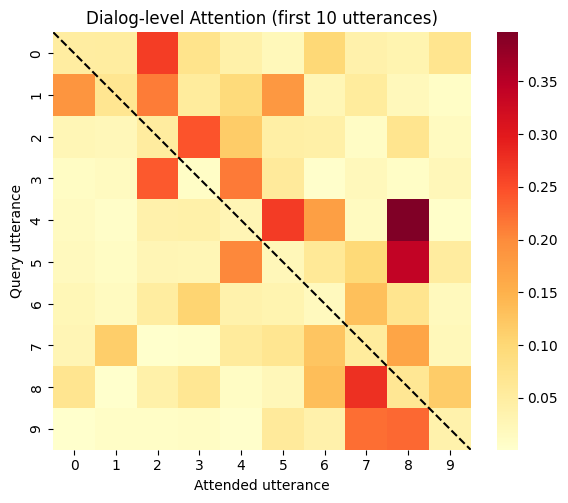

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Select a dialog from the test set
i = 0
emb, lbl, spk = test_dataset[i]
length = torch.tensor([len(lbl)], dtype=torch.long)

# Move to device and add batch dimension
emb = emb.unsqueeze(0).to(device)
spk = spk.unsqueeze(0).to(device)
length = length.to(device)

# Forward pass
model.eval()
with torch.no_grad():
    _ = model(emb, length, spk)

# Stack attention weights from all layers
attn_all = torch.stack([
    layer.attn_weights for layer in model.transformer_encoder.layers
])  # shape: [num_layers, batch, heads, seq, seq]

# Compute mean over layers and heads (for batch 0)
attn_mean = attn_all[:, 0].mean(dim=(0, 1)).cpu().numpy()  # shape: [seq, seq]

# Limit to first 10 utterances
attn_mean_trimmed = attn_mean[:10, :10]

# Plot heatmap with diagonal highlight
plt.figure(figsize=(6, 5))
ax = sns.heatmap(attn_mean_trimmed, cmap="YlOrRd", square=True)

# Add diagonal line (self-attention)
ax.plot(range(11), range(11), color='black', linestyle='--', linewidth=1.5)

plt.title("Dialog-level Attention (first 10 utterances)")
plt.xlabel("Attended utterance")
plt.ylabel("Query utterance")
plt.tight_layout()
plt.show()



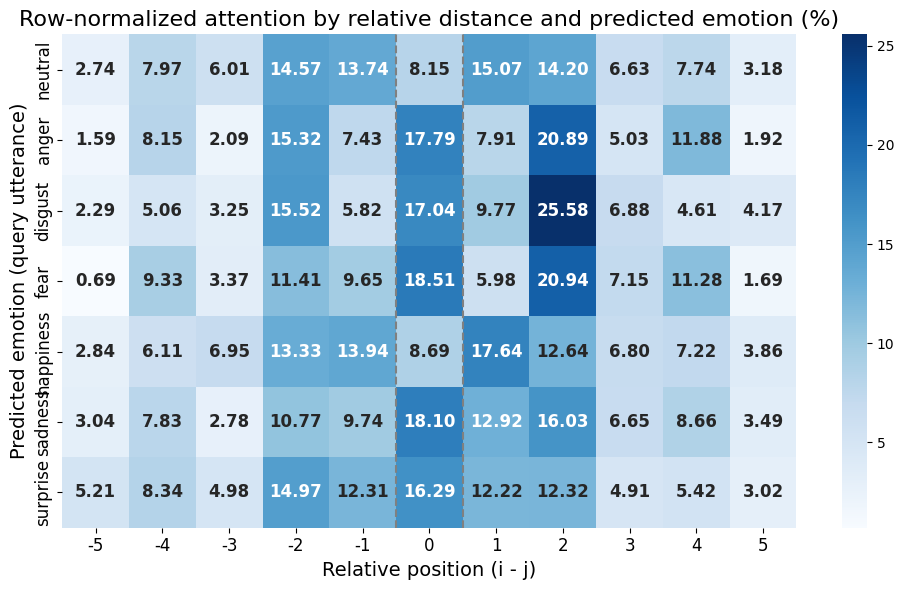

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

max_dist = 5
model.eval()

emotion_map = {
    0: "neutral",
    1: "anger",
    2: "disgust",
    3: "fear",
    4: "happiness",
    5: "sadness",
    6: "surprise"
}
num_emotions = len(emotion_map)
dist_range = list(range(-max_dist, max_dist + 1))

all_attn = {e: defaultdict(list) for e in range(num_emotions)}

for emb_batch, labels_batch, spk_batch, lengths in test_loader:
    emb_batch = emb_batch.to(device)
    spk_batch = spk_batch.to(device)
    lengths = lengths.to(device)

    with torch.no_grad():
        logits = model(emb_batch, lengths, spk_batch)
        preds = torch.argmax(logits, dim=-1)

    num_layers = len(model.transformer_encoder.layers)
    attn_all_layers = torch.stack([
        layer.attn_weights for layer in model.transformer_encoder.layers
    ])

    for b in range(emb_batch.size(0)):
        seq_len = lengths[b].item()
        pred_seq = preds[b][:seq_len].cpu()
        attn_map = attn_all_layers[:, b, :, :seq_len, :seq_len].mean(dim=(0, 1)).cpu()
        attn_map = attn_map / attn_map.sum(dim=1, keepdim=True)

        for i in range(seq_len):
            for j in range(seq_len):
                dist = i - j
                if abs(dist) > max_dist:
                    continue
                val = attn_map[i, j].item()
                emo = pred_seq[i].item()
                all_attn[emo][dist].append(val)

# Build heatmap: row-normalized per emotion
heat_data_normalized = []
row_labels = []

for emo_id in range(num_emotions):
    row = []
    for d in dist_range:
        vals = all_attn[emo_id][d]
        row.append(np.mean(vals) if vals else 0.0)
    row_sum = sum(row)
    norm_row = [round((v / row_sum) * 100, 2) if row_sum > 0 else 0.0 for v in row]
    heat_data_normalized.append(norm_row)
    row_labels.append(emotion_map[emo_id])

# Plot heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heat_data_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    annot_kws={"size": 12, "weight": "bold"},
    xticklabels=dist_range,
    yticklabels=row_labels
)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Relative position (i - j)", fontsize=14)
plt.ylabel("Predicted emotion (query utterance)", fontsize=14)
plt.title("Row-normalized attention by relative distance and predicted emotion (%)", fontsize=16)

center_col = dist_range.index(0)
ax.axvline(x=center_col, color='gray', linestyle='--', linewidth=1.5)
ax.axvline(x=center_col + 1, color='gray', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()


Example: 100%|██████████| 232/232 [00:22<00:00, 10.40it/s]


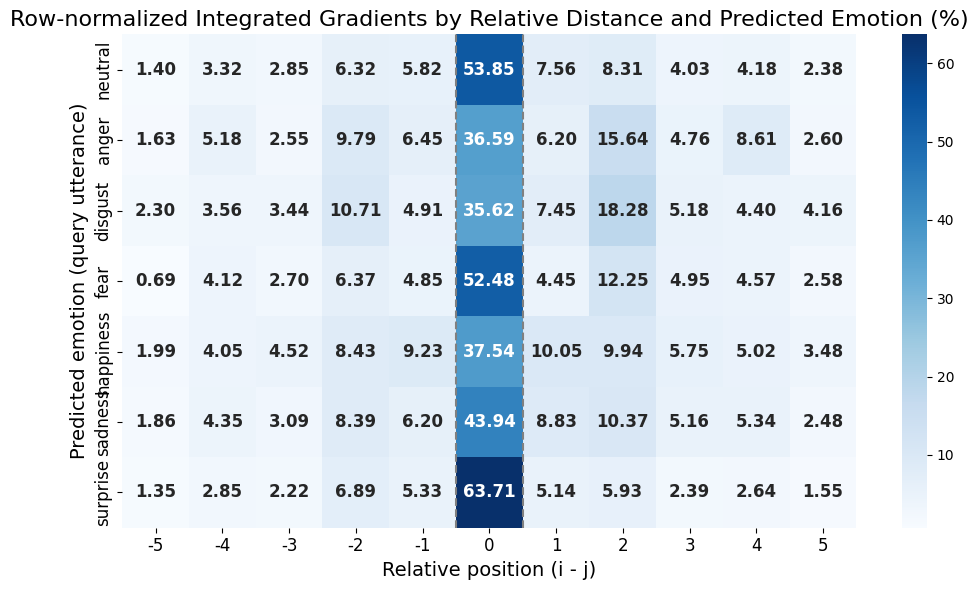

In [ ]:
from collections import defaultdict
from captum.attr import IntegratedGradients
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm

model.eval()
max_dist = 5
dist_range = list(range(-max_dist, max_dist + 1))
emotion_map = {
    0: "neutral", 1: "anger", 2: "disgust", 3: "fear",
    4: "happiness", 5: "sadness", 6: "surprise"
}
num_emotions = len(emotion_map)

ig_by_emotion = {e: defaultdict(list) for e in range(num_emotions)}

def forward_func(inputs, speaker_ids):
    batch_size, seq_len = inputs.shape[:2]
    lengths_tensor = torch.tensor([seq_len], device=inputs.device)
    logits = model(inputs, lengths_tensor, speaker_ids)
    probs = torch.softmax(logits, dim=-1)
    return probs[:, target_turn, :]

# Loop over batches
for emb_batch, lbl_batch, spk_batch, lengths in test_loader:
    emb_batch = emb_batch.to(device)
    spk_batch = spk_batch.to(device)

    for i in tqdm(range(emb_batch.size(0)), desc="Example"):
        seq_len = lengths[i].item()
        if seq_len < 2:
            continue

        emb_dialog = emb_batch[i:i+1, :seq_len]
        spk_dialog = spk_batch[i:i+1, :seq_len]

        with torch.no_grad():
            logits = model(emb_dialog, torch.tensor([seq_len], device=device), spk_dialog)
            preds = torch.argmax(logits, dim=-1).squeeze(0)[:seq_len]

        for target_turn in range(seq_len):
            target_label = preds[target_turn].item()

            ig = IntegratedGradients(forward_func)
            attributions = ig.attribute(
                inputs=emb_dialog,
                additional_forward_args=spk_dialog,
                target=target_label,
                return_convergence_delta=False
            )

            saliencies = attributions.squeeze(0).norm(p=2, dim=1).cpu().numpy()

            for ctx_turn in range(seq_len):
                rel_dist = target_turn - ctx_turn
                if abs(rel_dist) > max_dist:
                    continue
                ig_by_emotion[target_label][rel_dist].append(saliencies[ctx_turn])

# Build normalized heatmap: row = emotion, columns = distances, values in %
heat_data = []
row_labels = []

for emo_id in range(num_emotions):
    row = []
    for d in dist_range:
        vals = ig_by_emotion[emo_id][d]
        row.append(np.mean(vals) if vals else 0.0)
    row_sum = sum(row)
    norm_row = [(v / row_sum * 100) if row_sum > 0 else 0.0 for v in row]
    heat_data.append(norm_row)
    row_labels.append(emotion_map[emo_id])

# Plot heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heat_data,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    annot_kws={"size": 12, "weight": "bold"},
    xticklabels=dist_range,
    yticklabels=row_labels
)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Relative position (i - j)", fontsize=14)
plt.ylabel("Predicted emotion (query utterance)", fontsize=14)
plt.title("Row-normalized Integrated Gradients by Relative Distance and Predicted Emotion (%)", fontsize=16)

center_col = dist_range.index(0)
ax.axvline(x=center_col, color='gray', linestyle='--', linewidth=1.5)
ax.axvline(x=center_col + 1, color='gray', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()
